In [1]:
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

In [2]:
import os
import torch
import pandas as pd
import numpy as np
from glob import glob
from openslide import OpenSlide
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
model = CLIPModel.from_pretrained("vinid/plip")
processor = CLIPProcessor.from_pretrained("vinid/plip")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: vinid/plip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
df = pd.read_pickle('pkl/GI_cluster50_labelled_all_mar28.pkl') 
df.head() 

label     X      Y
paad TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC89... 0     0  1792  11264
                                                        1     0  1792  11520
                                                        2    46  2048   9984
                                                        3    46  2048  10240
                                                        4    46  2048  10496

In [46]:
new_df.shape

(85078334, 3)

In [9]:
new_df.columns

Index(['label', 'X', 'Y'], dtype='object')

In [10]:
df = df.reset_index() 
df.head() 

,level_0,level_1,level_2,label,X,Y
0,paad,TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC8...,0,0,1792,11264
1,paad,TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC8...,1,0,1792,11520
2,paad,TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC8...,2,46,2048,9984
3,paad,TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC8...,3,46,2048,10240
4,paad,TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC8...,4,46,2048,10496


In [18]:
df = df.rename(columns={'level_0': 'cancer_type', 'level_1': 'ID'})
count_df = df.groupby(['cancer_type', 'label']).size().reset_index(name='count')
noisy = [0, 3, 4, 7, 21, 27, 34, 39, 45, 46]
clean_df = count_df[~count_df['label'].isin(noisy)]
clean_df = clean_df[clean_df['cancer_type']!='luad']
clean_df.head()

/tmp/ipykernel_827681/4126935008.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df = df.groupby(['cancer_type', 'label']).size().reset_index(name='count')


,cancer_type,label,count
1,coad,1,46686
2,coad,2,200743
5,coad,5,28568
6,coad,6,316754
8,coad,8,103043


In [22]:
df.head()

,cancer_type,ID,level_2,label,X,Y
0,paad,TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC8...,0,0,1792,11264
1,paad,TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC8...,1,0,1792,11520
2,paad,TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC8...,2,46,2048,9984
3,paad,TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC8...,3,46,2048,10240
4,paad,TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC8...,4,46,2048,10496


In [19]:
clean_df.shape 

(200, 3)

(array([112.,  45.,  20.,   8.,   9.,   3.,   0.,   1.,   1.,   1.]),
 array([3.3000000e+01, 1.7784520e+05, 3.5565740e+05, 5.3346960e+05,
        7.1128180e+05, 8.8909400e+05, 1.0669062e+06, 1.2447184e+06,
        1.4225306e+06, 1.6003428e+06, 1.7781550e+06]),
 <BarContainer object of 10 artists>)

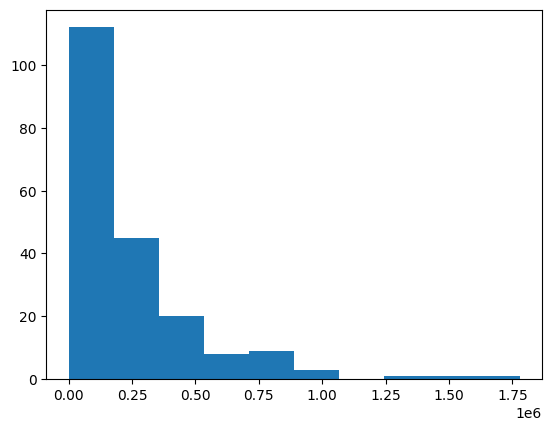

In [20]:
plt.hist(clean_df['count'])

In [21]:
# Use the bin edges from your histogram output
bin_edges = [3.3000000e+01, 1.7784520e+05, 3.5565740e+05, 5.3346960e+05,
        7.1128180e+05, 8.8909400e+05, 1.0669062e+06, 1.2447184e+06,
        1.4225306e+06, 1.6003428e+06, 1.7781550e+06]

# Create a new column 'bin_range'
clean_df['bin_range'] = pd.cut(clean_df['count'], bins=bin_edges)

# Display the top entries sorted by count to see the high-frequency bins
clean_df.sort_values('count').head(20)

,cancer_type,label,count,bin_range
214,read,14,33,NaN
64,esca,14,118,"(33.0, 177845.2]"
14,coad,14,168,"(33.0, 177845.2]"
243,read,43,256,"(33.0, 177845.2]"
218,read,18,1262,"(33.0, 177845.2]"
43,coad,43,1539,"(33.0, 177845.2]"
160,paad,10,1768,"(33.0, 177845.2]"
220,read,20,1845,"(33.0, 177845.2]"
176,paad,26,6533,"(33.0, 177845.2]"
79,esca,29,6895,"(33.0, 177845.2]"


In [6]:
miscellaneous = [5,9,10,14,18,20,26,29,35,36,43]
noisy = [0, 3, 4, 7, 21, 27, 34, 39, 45, 46]
# Combine both lists to create a single exclusion set
exclude = set(miscellaneous + noisy)

# Generate the filtered list
clean_clusters = [i for i in range(50) if i not in exclude]

len(clean_clusters) 

29

In [6]:
cluster = 14

In [56]:
filtered_df = new_df[new_df['label'] == cluster]
filtered_df = filtered_df.reset_index() 
filtered_df 

,level_0,level_1,level_2,label,X,Y
0,paad,TCGA-IB-A5SP-01Z-00-DX1.0D3C9A7E-F73C-4F03-98C...,245,1,9472,61952
1,paad,TCGA-IB-A5SP-01Z-00-DX1.0D3C9A7E-F73C-4F03-98C...,273,1,9728,61696
2,paad,TCGA-IB-A5SP-01Z-00-DX1.0D3C9A7E-F73C-4F03-98C...,456,1,11264,58112
3,paad,TCGA-IB-A5SP-01Z-00-DX1.0D3C9A7E-F73C-4F03-98C...,5439,1,26880,42240
4,paad,TCGA-IB-A5SP-01Z-00-DX1.0D3C9A7E-F73C-4F03-98C...,8411,1,31488,80384
...,...,...,...,...,...,...
1521424,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,32928,1,78592,27136
1521425,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,32972,1,78848,12288
1521426,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,33179,1,79360,15104
1521427,read,TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-935...,34574,1,83456,13824


In [59]:
filtered_df = filtered_df.rename(columns={'level_0': 'cancer_type', 'level_1': 'ID'}) 
filtered_df = filtered_df[~(filtered_df['cancer_type'] == 'luad')]
sample_df = filtered_df.groupby('cancer_type').sample(n=200, random_state=1, replace=False)
final_df = sample_df[['cancer_type', 'label', 'ID', 'X', 'Y']]
final_df.head()

,cancer_type,label,ID,X,Y
283344,coad,1,TCGA-D5-6929-01Z-00-DX1.5e555bba-87b2-440c-b6d...,103936,35840
255207,coad,1,TCGA-A6-A56B-01Z-00-DX1.52FE9FA5-05F1-49EA-98B...,59136,10240
269954,coad,1,TCGA-4T-AA8H-01Z-00-DX1.A46C759C-74A2-4724-B6B...,43264,76800
254043,coad,1,TCGA-QL-A97D-01Z-00-DX1.6B48E95D-BE3C-4448-A1A...,48896,77568
280126,coad,1,TCGA-NH-A6GC-01Z-00-DX1.29073D7E-5EEF-4BBA-96B...,36096,66816


In [58]:
final_df.shape

(1000, 4)

In [16]:
filtered_df = df[df['cluster'] == cluster]
sample_df = filtered_df.groupby('cancer_type').sample(n=200, random_state=1, replace=False)
final_df = sample_df[['cancer_type', 'cluster', 'X', 'Y']]
final_df.head()

cancer_type  \
coad TCGA-5M-AATE-01Z-00-DX1.483FFD2F-61A1-477E-8F94... 2324        coad   
                                                        890         coad   
     TCGA-D5-6534-01Z-00-DX1.eb7b12b8-ad31-438f-8e1d... 1416        coad   
     TCGA-AY-A54L-01Z-00-DX1.BD4039B4-D732-418B-9CC9... 336         coad   
     TCGA-NH-A8F7-01Z-00-DX1.5CB8911D-07C3-4EF2-A97D... 127         coad   

                                                              cluster  \
coad TCGA-5M-AATE-01Z-00-DX1.483FFD2F-61A1-477E-8F94... 2324        1   
                                                        890         1   
     TCGA-D5-6534-01Z-00-DX1.eb7b12b8-ad31-438f-8e1d... 1416        1   
     TCGA-AY-A54L-01Z-00-DX1.BD4039B4-D732-418B-9CC9... 336         1   
     TCGA-NH-A8F7-01Z-00-DX1.5CB8911D-07C3-4EF2-A97D... 127         1   

                                                                     X  \
coad TCGA-5M-AATE-01Z-00-DX1.483FFD2F-61A1-477E-8F94... 2324   66048.0   
                                                        890    33792.0   
     TCGA-D5-6534-01Z-00-DX1.eb7b12b8-ad31-438f-8e1d... 1416  133120.0   
     TCGA-AY-A54L-01Z-00-DX1.BD4039B4-D732-418B-9CC9... 336    24320.0   
     TCGA-NH-A8F7-01Z-00-DX1.5CB8911D-07C3-4EF2-A97D... 127    18176.0   

                                                                    Y  
coad TCGA-5M-AATE-01Z-00-DX1.483FFD2F-61A1-477E-8F94... 2324  49664.0  
                                                        890   39936.0  
     TCGA-D5-6534-01Z-00-DX1.eb7b12b8-ad31-438f-8e1d... 1416  29184.0  
     TCGA-AY-A54L-01Z-00-DX1.BD4039B4-D732-418B-9CC9... 336   31488.0  
     TCGA-NH-A8F7-01Z-00-DX1.5CB8911D-07C3-4EF2-A97D... 127   32256.0

In [17]:
final_df['cancer_type'].value_counts()

cancer_type
coad    200
esca    200
paad    200
read    200
stad    200
Name: count, dtype: int64

In [18]:
sample_df = data.iloc[0]
sample_df 

NameError: name 'data' is not defined

In [9]:
sample_df['id']

'TCGA-A6-4107-01Z-00-DX1.89bf3dd5-72a6-49cc-9857-df2c36884029'

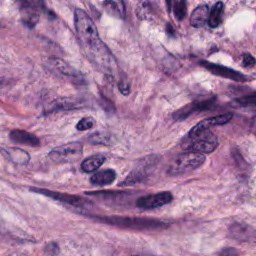

In [12]:
#need to define dimensions? 
slide = OpenSlide('{}_new/{}.svs'.format(sample_df['cancer_type'].upper(), sample_df['id']))
mag = int(slide.properties['openslide.objective-power'])
num_read = int(256* mag/40) #downsampling different for new dataset, no longer 512 
x = int(sample_df['X'])
y = int(sample_df['Y']) 
image = slide.read_region(level = 0, location = (x,y), size = (num_read,num_read))
display(image)

In [5]:

labels = [
    # Neoplasia
    "tubular adenocarcinoma", 
    "signet ring cell carcinoma",
    "diffuse-type carcinoma",
    "poorly differentiated carcinoma",
    "moderately differentiated adenocarcinoma",
    "well-differentiated adenocarcinoma",
    "malignant columnar epithelium",

    # Dysplasia
    "high-grade dysplasia with cribriforming glands",
    "low-grade dysplasia with cigar-shaped nuclei",
    "non-neoplastic changes",

    # Metaplasia
    "intestinal metaplasia with goblet cells",
    
    # Normal / Structural
    "normal mucosal lining, surface epithelium",
    "submucosal layer, connective tissue and vessels",
    "smooth muscle tissue",
    "desmoplastic stroma with fibroblasts",
    "fibrotic stroma and collagen deposition",
    "extracellular mucin pools",
    
    # Immune and Inflammation
    "lymphoid aggregate and lymphoid follicle",
    "mature lymphocytes with dense nuclei",
    "plasma cells with eccentric nuclei",
    "acute inflammation with neutrophils",
    "extravasated red blood cells, hemorrhage",
    "lymphovascular invasion, tumor emboli",
    "mononuclear inflammatory infiltrate",
    "necrotic debris",
]        
    

In [30]:
inputs = processor(text= labels, images=image, return_tensors="pt", padding=True)

In [31]:
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  
print(probs)

tensor([[2.3561e-03, 1.0194e-03, 5.2101e-03, 4.4625e-03, 2.3494e-02, 1.3141e-03,
         2.5414e-04, 2.2092e-03, 8.3227e-02, 6.5583e-04, 1.4184e-04, 1.2506e-04,
         5.6022e-03, 1.6341e-03, 2.0705e-03, 1.7988e-02, 1.3832e-02, 2.3734e-03,
         1.8437e-02, 5.5134e-03, 7.9758e-04, 1.3537e-01, 4.0872e-03, 8.1038e-03,
         1.1744e-01, 4.6210e-03, 2.4685e-02, 2.9334e-03, 6.6038e-04, 4.6661e-03,
         2.8295e-01, 2.2686e-04, 2.0247e-04, 1.4208e-03, 1.3707e-02, 6.6771e-03,
         5.5585e-02, 7.0153e-03, 2.7003e-02, 1.0994e-01]],
       grad_fn=<SoftmaxBackward0>)


In [32]:
# 2. Get the index of the highest probability
max_prob, max_idx = torch.max(probs, dim=1)

# 3. Convert to scalar and retrieve text
predicted_label = labels[max_idx.item()]
confidence = max_prob.item()

print(f"Top Prediction: {predicted_label}")
print(f"Confidence: {confidence:.4f}")

Top Prediction: a patch showing myoepithelial cells with spindle morphology at the base of glands
Confidence: 0.2829


In [33]:
max_idx

tensor([30])

In [9]:
df 

label      X  \
paad TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC89... 0         0   1792   
                                                        1         0   1792   
                                                        2        46   2048   
                                                        3        46   2048   
                                                        4        46   2048   
...                                                             ...    ...   
read TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-9352... 36609    13  94208   
                                                        36610    29  94208   
                                                        36611    29  94208   
                                                        36612    13  94208   
                                                        36613    13  94208   

                                                                   Y  
paad TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC89... 0      11264  
                                                        1      11520  
                                                        2       9984  
                                                        3      10240  
                                                        4      10496  
...                                                              ...  
read TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-9352... 36609  20736  
                                                        36610  20992  
                                                        36611  21248  
                                                        36612  21504  
                                                        36613  21760  

[85078334 rows x 3 columns]

In [10]:
filtered_df = df[df['label'] == 14]
#sample_df = filtered_df.groupby('cancer_type').sample(n=200, random_state=1, replace=False)
sample_df = filtered_df.sample(n=1000, random_state=1, replace=False)
sample_df = sample_df.reset_index() 
sample_df = sample_df.rename(columns={'level_1': 'ID'}) 
sample_df 

,level_0,ID,level_2,label,X,Y
0,paad,TCGA-IB-A7M4-01Z-00-DX1.4B58AE26-6F2F-4463-A9B...,78099,14,135936,17152
1,paad,TCGA-3A-A9IC-01Z-00-DX1.C41BADB4-1DC2-41EC-857...,27708,14,36096,32768
2,paad,TCGA-XD-AAUL-01Z-00-DX1.45D24E87-C851-49EC-B10...,17093,14,43264,60416
3,paad,TCGA-HV-A7OL-11Z-00-DX1.47B5AB55-F723-40B4-B69...,14501,14,22272,50176
4,paad,TCGA-XD-AAUG-01Z-00-DX4.722A2015-9286-49C2-8DF...,71591,14,90368,58368
...,...,...,...,...,...,...
995,paad,TCGA-XD-AAUH-01Z-00-DX5.BA7E6EED-124E-4A52-B97...,2178,14,12288,47104
996,paad,TCGA-HV-AA8X-11Z-00-DX1.F976E711-34F6-4F00-B30...,2939,14,20224,27904
997,paad,TCGA-2J-AAB1-01Z-00-DX1.F3B4818F-9C3B-4C66-824...,36243,14,77824,46080
998,paad,TCGA-FB-A7DR-01Z-00-DX1.98E77908-E193-45B8-B97...,49166,14,63488,15616


In [11]:
sample_df['level_0'].value_counts()

level_0
paad    960
stad     40
Name: count, dtype: int64

In [17]:
sample_df['cancer_type'].value_counts() 

cancer_type
coad    5
esca    5
paad    5
read    5
stad    5
Name: count, dtype: int64

In [13]:
cluster_list = [14]
counts_df = pd.DataFrame(0, index=cluster_list, columns=range(len(labels)))

# Confidence: Rows = Clusters, Columns = Sample indices 
confidence_df = pd.DataFrame(np.nan, index=cluster_list, columns=range(1000))


In [15]:
from tqdm import tqdm
for i, (idx, row) in enumerate(sample_df.iterrows()): 
        
        slide = OpenSlide('{}_new/{}.svs'.format(row['level_0'].upper(), row['ID']))
        mag = int(slide.properties['openslide.objective-power'])
        num_read = int(256* mag/40) #downsampling different for new dataset, no longer 512 
        x = int(row['X'])
        y = int(row['Y']) 
        image = slide.read_region(level = 0, location = (x,y), size = (num_read,num_read))

        inputs = processor(text= labels, images=image, return_tensors="pt", padding=True)
        outputs = model(**inputs)
        logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
        probs = logits_per_image.softmax(dim=1)  #probabilities of the text labels using softmax 
        
        max_prob, max_idx = torch.max(probs, dim=1) #max probability and index of the label with max probability 
        
        #predicted_label = labels[max_idx.item()] 
        confidence = max_prob.item()
        label = max_idx.item() 

        # Increment the count for the winning label in this cluster
        counts_df.at[cluster, label] += 1
        
        # Store the confidence value at the specific sample index (i)
        confidence_df.at[cluster, i] = confidence

max_prob_df = counts_df.idxmax(axis=1)

In [16]:
max_prob_df 

14    19
dtype: int64

In [30]:
from tqdm import tqdm

n = 10
# 1. Initialize result dataframes
# Labels count: Rows = Clusters, Columns = Index of text labels 
noisy = [0, 3, 4, 7, 14, 21, 27, 34, 39, 45, 46]
cluster_list = [i for i in range(50) if i not in noisy]
counts_df = pd.DataFrame(0, index=cluster_list, columns=range(len(labels)))

# Confidence: Rows = Clusters, Columns = Sample indices 
confidence_df = pd.DataFrame(np.nan, index=cluster_list, columns=range(5*n))

df = df.reset_index() 
df = df.rename(columns={'level_0': 'cancer_type', 'level_1': 'ID'})
df = df[df['cancer_type']!='luad'] 
df = df[~df['label'].isin(noisy)]

for cluster in tqdm(cluster_list): 
    filtered_df = df[df['label'] == cluster]
    #do the filtering outside then do random sampling within the for loop or else computationally expensive 
    sample_df = filtered_df.groupby('cancer_type').sample(n=10, random_state=1, replace=False)
    
    for i, (idx, row) in enumerate(sample_df.iterrows()): 
        
        slide = OpenSlide('{}_new/{}.svs'.format(row['cancer_type'].upper(), row['ID']))
        mag = int(slide.properties['openslide.objective-power'])
        num_read = int(256* mag/40) #downsampling different for new dataset, no longer 512 
        x = int(row['X'])
        y = int(row['Y']) 
        image = slide.read_region(level = 0, location = (x,y), size = (num_read,num_read))

        inputs = processor(text= labels, images=image, return_tensors="pt", padding=True)
        outputs = model(**inputs)
        logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
        probs = logits_per_image.softmax(dim=1)  #probabilities of the text labels using softmax 
        
        max_prob, max_idx = torch.max(probs, dim=1) #max probability and index of the label with max probability 
        
        #predicted_label = labels[max_idx.item()] 
        confidence = max_prob.item()
        label = max_idx.item() 

        # Increment the count for the winning label in this cluster
        counts_df.at[cluster, label] += 1
        
        # Store the confidence value at the specific sample index (i)
        confidence_df.at[cluster, i] = confidence

max_prob_df = counts_df.idxmax(axis=1)

100%|███████████████████████████████████| 39/39 [09:00<00:00, 13.86s/it]


In [31]:
probs

tensor([[6.5113e-04, 2.9490e-04, 5.8596e-03, 1.6684e-03, 2.7395e-04, 4.3742e-05,
         6.3175e-06, 1.2555e-04, 8.5190e-04, 1.0443e-04, 7.3342e-05, 2.2549e-04,
         9.5672e-04, 1.3767e-03, 1.6692e-03, 2.0863e-03, 3.4309e-03, 1.3449e-03,
         2.7217e-02, 6.1934e-04, 4.7979e-04, 5.4787e-02, 2.0470e-02, 2.7145e-02,
         2.3368e-01, 6.6220e-03, 2.4990e-01, 6.2263e-02, 8.9117e-04, 6.2665e-03,
         5.7165e-02, 5.3761e-06, 2.1008e-04, 4.3253e-03, 1.4869e-04, 3.0364e-02,
         2.4222e-02, 5.9452e-05, 3.6168e-02, 1.3595e-01]],
       grad_fn=<SoftmaxBackward0>)

In [32]:
max_prob_df

1      8
2     26
5     21
6     24
8     27
9     27
10    27
11    27
12     8
13    27
15    22
16    21
17    33
18     8
19    27
20    30
22    26
23     0
24    27
25    22
26     8
28    21
29    16
30    22
31    21
32    22
33    21
35    21
36    27
37    21
38    27
40    21
41    27
42    21
43    27
44    27
47    22
48    21
49    21
dtype: int64

In [33]:
max_prob_df.unique() 

array([ 8, 26, 21, 24, 27, 22, 33, 30,  0, 16])

In [40]:
max_prob_df.to_list()

[8,
 27,
 36,
 27,
 27,
 8,
 27,
 22,
 21,
 33,
 27,
 24,
 21,
 27,
 22,
 21,
 22,
 27,
 22,
 21,
 21,
 27,
 21,
 27,
 21,
 27,
 22,
 21,
 21]

In [34]:
confidence_df

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
1,0.292876,0.366794,0.232583,0.334402,0.312466,0.273291,0.235129,0.381985,0.377577,0.462024,...,0.227272,0.968260,0.290488,0.254730,0.300377,0.478830,0.245756,0.303436,0.317081,0.192584
2,0.394580,0.368858,0.391883,0.580439,0.510978,0.228921,0.371714,0.195065,0.584598,0.311788,...,0.401587,0.525106,0.247271,0.219801,0.218784,0.575820,0.625433,0.133427,0.175256,0.367247
5,0.345406,0.871467,0.308366,0.306725,0.554198,0.389949,0.385727,0.230997,0.593392,0.478518,...,0.564894,0.306098,0.265833,0.382759,0.681726,0.477728,0.984793,0.439032,0.145662,0.579576
6,0.110668,0.804149,0.581398,0.503677,0.873133,0.523012,0.527148,0.222160,0.496949,0.402831,...,0.379390,0.466525,0.237073,0.225919,0.214983,0.195967,0.449616,0.430827,0.234024,0.386855
8,0.885355,0.465517,0.388802,0.410105,0.341461,0.704159,0.553451,0.886910,0.470780,0.228104,...,0.296750,0.687920,0.407052,0.515512,0.575156,0.288158,0.432102,0.439135,0.553313,0.371936
9,0.172499,0.260496,0.190982,0.844735,0.894106,0.269487,0.383900,0.201371,0.440467,0.280369,...,0.174257,0.235432,0.628028,0.212359,0.461892,0.147503,0.300105,0.483493,0.413021,0.308477
10,0.273581,0.423066,0.220690,0.316208,0.237368,0.661344,0.571968,0.685648,0.407230,0.193779,...,0.414818,0.570632,0.170516,0.486598,0.478360,0.641652,0.300073,0.785748,0.324183,0.311570
11,0.524267,0.578372,0.306572,0.459787,0.249701,0.473591,0.494495,0.843312,0.343041,0.720668,...,0.474390,0.399977,0.599225,0.610571,0.906803,0.828767,0.521262,0.816113,0.314266,0.630593
12,0.230110,0.280850,0.201349,0.269129,0.865005,0.560887,0.537184,0.306409,0.341300,0.400568,...,0.399008,0.261427,0.451947,0.237344,0.390272,0.271194,0.281929,0.240839,0.440349,0.274869
13,0.709821,0.281229,0.578240,0.419379,0.925009,0.281527,0.295162,0.361200,0.238503,0.197723,...,0.294261,0.466391,0.305290,0.238787,0.362285,0.658280,0.211897,0.665767,0.239259,0.432595


In [35]:
counts_df 

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
1,2,0,1,0,1,0,0,0,15,0,...,14,0,0,3,0,0,0,0,0,0
2,1,0,0,2,1,0,0,0,2,0,...,3,0,0,4,0,0,2,0,3,5
5,0,0,0,0,0,0,0,0,0,0,...,3,0,0,0,0,0,0,0,0,13
6,0,0,0,1,0,0,0,0,4,0,...,4,0,0,4,0,0,1,0,0,4
8,0,0,0,1,0,4,0,0,8,0,...,0,0,0,4,0,0,0,0,0,1
9,3,0,0,1,0,2,0,0,19,0,...,2,0,0,0,0,0,0,0,0,0
10,0,0,3,1,2,9,0,0,10,0,...,0,0,0,0,0,0,0,0,0,0
11,1,0,0,0,0,2,0,0,16,0,...,0,0,0,2,0,0,0,0,0,0
12,2,0,0,3,0,3,0,0,18,0,...,0,0,0,1,0,0,0,0,0,0
13,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,1,1,0,3,0


In [36]:
counts_df.sum(axis=1) 

1     50
2     50
5     50
6     50
8     50
9     50
10    50
11    50
12    50
13    50
15    50
16    50
17    50
18    50
19    50
20    50
22    50
23    50
24    50
25    50
26    50
28    50
29    50
30    50
31    50
32    50
33    50
35    50
36    50
37    50
38    50
40    50
41    50
42    50
43    50
44    50
47    50
48    50
49    50
dtype: int64

In [17]:
max_prob_df = pd.read_pickle('pkl/PLIP_annotation_final_v2.pkl') 
counts_df = pd.read_pickle('pkl/PLIP_annotation_counts_v2.pkl') 
confidence_df = pd.read_pickle('pkl/PLIP_annotation_confidence_v2.pkl') 

In [4]:
confidence_df 

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
1,0.581426,0.455653,0.443977,0.478025,0.259465,0.302446,0.288067,0.459190,0.292671,0.276665,...,0.547469,0.363422,0.372053,0.575853,0.493253,0.426183,0.249885,0.319282,0.277667,0.183234
2,0.879371,0.474729,0.573121,0.898876,0.509275,0.386131,0.465126,0.409101,0.577364,0.665309,...,0.287214,0.620025,0.153746,0.400897,0.667648,0.484176,0.624629,0.391609,0.485555,0.429455
5,0.834271,0.396568,0.753652,0.496110,0.738374,0.632141,0.564380,0.751238,0.803596,0.883973,...,0.407926,0.587168,0.283693,0.347639,0.687081,0.682148,0.271050,0.645181,0.557309,0.638111
6,0.427650,0.265634,0.486631,0.217866,0.591625,0.447660,0.495791,0.413480,0.729162,0.655609,...,0.194415,0.202598,0.340885,0.330306,0.237484,0.306400,0.441095,0.633042,0.221174,0.818609
8,0.370882,0.597431,0.437952,0.359844,0.259004,0.634623,0.187488,0.199426,0.584680,0.386130,...,0.423166,0.271590,0.360735,0.445539,0.334574,0.316974,0.308133,0.363721,0.337284,0.623885
9,0.278576,0.430291,0.381047,0.275810,0.301718,0.388582,0.333295,0.456169,0.377097,0.423616,...,0.237983,0.182574,0.293148,0.376082,0.357487,0.238303,0.393892,0.238376,0.362794,0.247101
10,0.699378,0.500702,0.235387,0.369255,0.663689,0.434331,0.387665,0.406204,0.454653,0.396458,...,0.316201,0.271172,0.335250,0.440371,0.263587,0.235738,0.474689,0.202538,0.476052,0.398335
11,0.305622,0.306966,0.565310,0.456978,0.299186,0.407153,0.275387,0.208378,0.184531,0.543418,...,0.449852,0.222353,0.398999,0.449794,0.624879,0.344280,0.365860,0.309725,0.542605,0.313078
12,0.241170,0.313008,0.202433,0.448378,0.537832,0.540304,0.422493,0.420394,0.304942,0.514232,...,0.414343,0.497729,0.367066,0.287995,0.282237,0.338768,0.281136,0.411600,0.313980,0.254666
13,0.613838,0.259231,0.403452,0.522637,0.699224,0.765114,0.378198,0.740363,0.270055,0.518277,...,0.440285,0.873060,0.336849,0.404792,0.483940,0.508600,0.257964,0.263490,0.655618,0.234606


In [19]:
confidence_df.mean(axis=1) 

1     0.419345
2     0.465515
5     0.659501
6     0.469717
8     0.411883
9     0.401440
10    0.368104
11    0.398514
12    0.390261
13    0.477929
15    0.384068
16    0.648281
17    0.519345
18    0.386682
19    0.435506
20    0.546286
22    0.542733
23    0.500129
24    0.377788
25    0.402065
26    0.411513
28    0.679341
29    0.514409
30    0.550459
31    0.597723
32    0.430519
33    0.613462
35    0.607622
36    0.457515
37    0.698912
38    0.352173
40    0.854409
41    0.379990
42    0.510921
43    0.468194
44    0.466790
47    0.606816
48    0.504976
49    0.547602
dtype: float64

In [21]:
confidence_df.mean(axis=1).mean()

np.float64(0.4989342465945161)

Text(0.5, 1.0, 'Average Max Probability for PLIP Zero Shot')

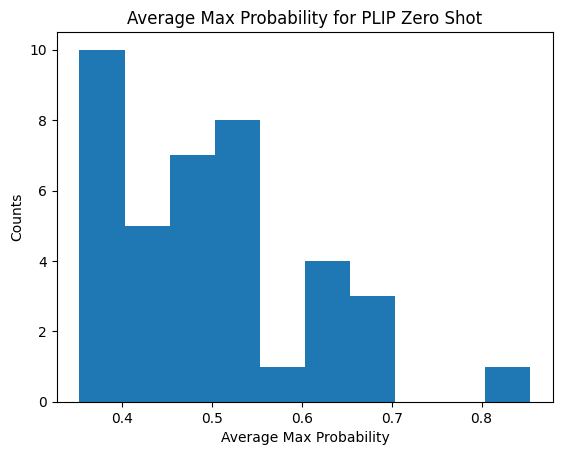

In [18]:
plt.hist(confidence_df.mean(axis=1)) 
plt.xlabel('Average Max Probability') 
plt.ylabel('Counts') 
plt.title('Average Max Probability for PLIP Zero Shot') 

In [ ]:
max_prob

In [21]:
max_prob_df 

1     14
2     14
5     14
6     14
8     23
9      6
10     2
11     6
12     6
13    21
15    19
16    14
17    23
18    11
19     6
20    14
22    14
23    19
24     6
25    16
26     6
28    13
29    10
30    14
31    13
32    14
33    13
35    13
36    23
37    13
38     6
40    13
41    23
42    13
43    10
44    21
47    21
48    14
49    13
dtype: int64

In [22]:
max_prob_df.value_counts() 

14    10
13     8
6      7
23     4
21     3
19     2
10     2
2      1
16     1
11     1
Name: count, dtype: int64

In [23]:
label_dict = {i: label for i, label in enumerate(labels)}
label_dict 

{0: 'tubular adenocarcinoma',
 1: 'signet ring cell carcinoma',
 2: 'diffuse-type carcinoma',
 3: 'poorly differentiated carcinoma',
 4: 'moderately differentiated adenocarcinoma',
 5: 'well-differentiated adenocarcinoma',
 6: 'malignant columnar epithelium',
 7: 'high-grade dysplasia with cribriforming glands',
 8: 'low-grade dysplasia with cigar-shaped nuclei',
 9: 'non-neoplastic changes',
 10: 'intestinal metaplasia with goblet cells',
 11: 'normal mucosal lining, surface epithelium',
 12: 'submucosal layer, connective tissue and vessels',
 13: 'smooth muscle tissue',
 14: 'desmoplastic stroma with fibroblasts',
 15: 'fibrotic stroma and collagen deposition',
 16: 'extracellular mucin pools',
 17: 'lymphoid aggregate and lymphoid follicle',
 18: 'mature lymphocytes with dense nuclei',
 19: 'plasma cells with eccentric nuclei',
 20: 'acute inflammation with neutrophils',
 21: 'extravasated red blood cells, hemorrhage',
 22: 'lymphovascular invasion, tumor emboli',
 23: 'mononuclear 

In [24]:
# Map the numeric indices to the text descriptions
max_prob_labels = max_prob_df.map(label_dict)
pd.set_option('display.max_columns', None)
max_prob_labels 

1          desmoplastic stroma with fibroblasts
2          desmoplastic stroma with fibroblasts
5          desmoplastic stroma with fibroblasts
6          desmoplastic stroma with fibroblasts
8           mononuclear inflammatory infiltrate
9                 malignant columnar epithelium
10                       diffuse-type carcinoma
11                malignant columnar epithelium
12                malignant columnar epithelium
13     extravasated red blood cells, hemorrhage
15           plasma cells with eccentric nuclei
16         desmoplastic stroma with fibroblasts
17          mononuclear inflammatory infiltrate
18    normal mucosal lining, surface epithelium
19                malignant columnar epithelium
20         desmoplastic stroma with fibroblasts
22         desmoplastic stroma with fibroblasts
23           plasma cells with eccentric nuclei
24                malignant columnar epithelium
25                    extracellular mucin pools
26                malignant columnar epi

In [25]:
max_prob_df.unique() 

array([14, 23,  6,  2, 21, 19, 11, 16, 13, 10])